# Credit Risk Scorecard | Goldman Sachs Risk Analyst Project

## Objective
Build a credit risk scorecard to predict probability of loan default 
using real-world borrower data (150,000 records).

## Key Results
- ROC-AUC: 0.76
- Successfully stratified borrowers into 4 risk bands (1.7% → 17.2% default rate)
- Top predictor: Past delinquency history

## Tech Stack
Python | pandas | scikit-learn | imbalanced-learn | matplotlib | seaborn

## Dataset
Give Me Some Credit — Kaggle

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
df = pd.read_csv('cs-training.csv')
print(df.shape)


(150000, 12)


In [33]:
print(df.head())


   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [34]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [35]:
print(df.describe())

          Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
count  150000.000000     150000.000000                         150000.000000   
mean    75000.500000          0.066840                              6.048438   
std     43301.414527          0.249746                            249.755371   
min         1.000000          0.000000                              0.000000   
25%     37500.750000          0.000000                              0.029867   
50%     75000.500000          0.000000                              0.154181   
75%    112500.250000          0.000000                              0.559046   
max    150000.000000          1.000000                          50708.000000   

                 age  NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  \
count  150000.000000                         150000.000000  150000.000000   
mean       52.295207                              0.421033     353.005076   
std        14.771866                            

In [36]:
print(df.isnull().sum())

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [37]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

In [38]:
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0])


In [39]:
print(df.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [40]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


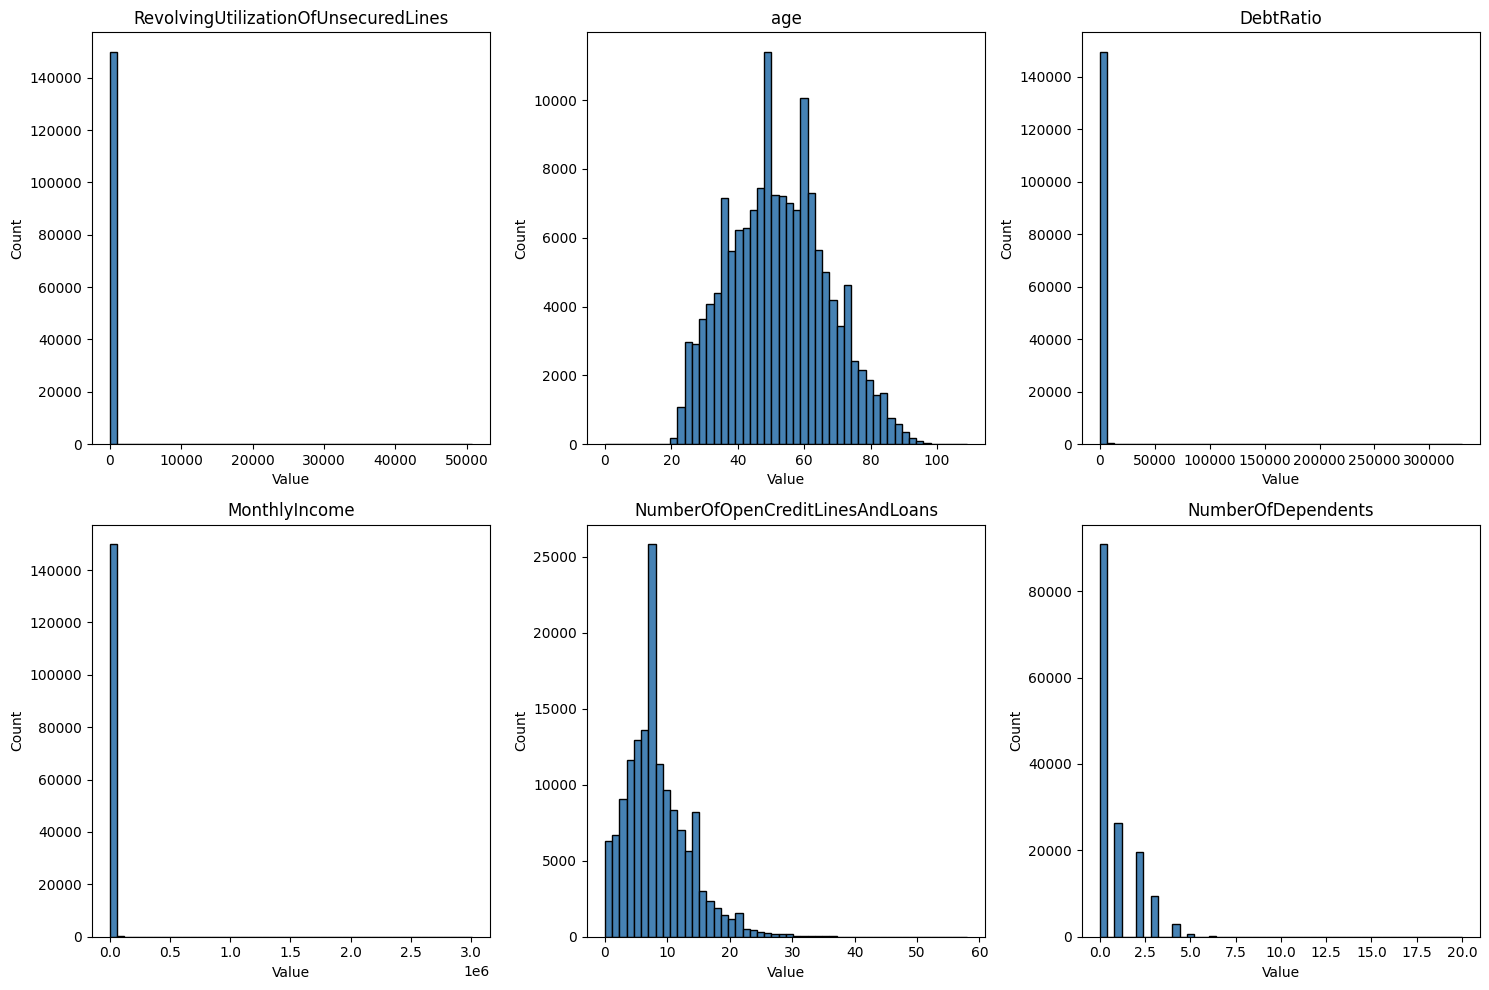

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols = ['RevolvingUtilizationOfUnsecuredLines', 'age', 
        'DebtRatio', 'MonthlyIncome', 
        'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']

for i, col in enumerate(cols):
    axes[i//3][i%3].hist(df[col], bins=50, color='steelblue', edgecolor='black')
    axes[i//3][i%3].set_title(col)
    axes[i//3][i%3].set_xlabel('Value')
    axes[i//3][i%3].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Exploratory Data Analysis
Key findings:
- Borrowers aged 25-35 have the highest default rate
- High credit utilization (80-100%) leads to 21% default rate vs 1.9% for low utilization
- Past delinquency history is the strongest predictor of future default

C:\Users\Asus\AppData\Local\Temp\ipykernel_10972\2736647229.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_age = df.groupby('age_bin')['SeriousDlqin2yrs'].mean() * 100


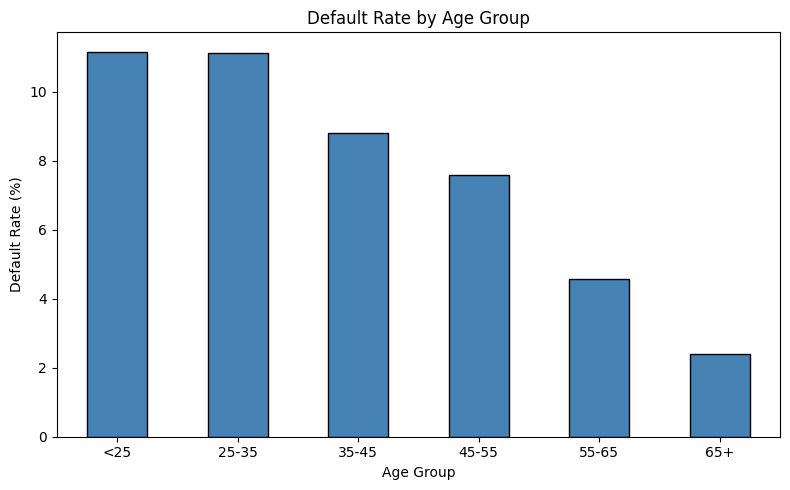

age_bin
<25      11.166171
25-35    11.122548
35-45     8.813173
45-55     7.593350
55-65     4.583009
65+       2.410271
Name: SeriousDlqin2yrs, dtype: float64


In [42]:
# Create age bins
df['age_bin'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100], 
                        labels=['<25','25-35','35-45','45-55','55-65','65+'])

default_by_age = df.groupby('age_bin')['SeriousDlqin2yrs'].mean() * 100

plt.figure(figsize=(8,5))
default_by_age.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(default_by_age)

In [43]:

df['utilization_capped'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# Bin it
df['util_bin'] = pd.cut(df['utilization_capped'], 
                         bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                         labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])

default_by_util = df.groupby('util_bin')['SeriousDlqin2yrs'].mean() * 100

print(default_by_util)

util_bin
0-20%       1.873473
20-40%      4.389236
40-60%      7.604419
60-80%     11.933056
80-100%    21.079855
Name: SeriousDlqin2yrs, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_10972\2090066256.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_util = df.groupby('util_bin')['SeriousDlqin2yrs'].mean() * 100


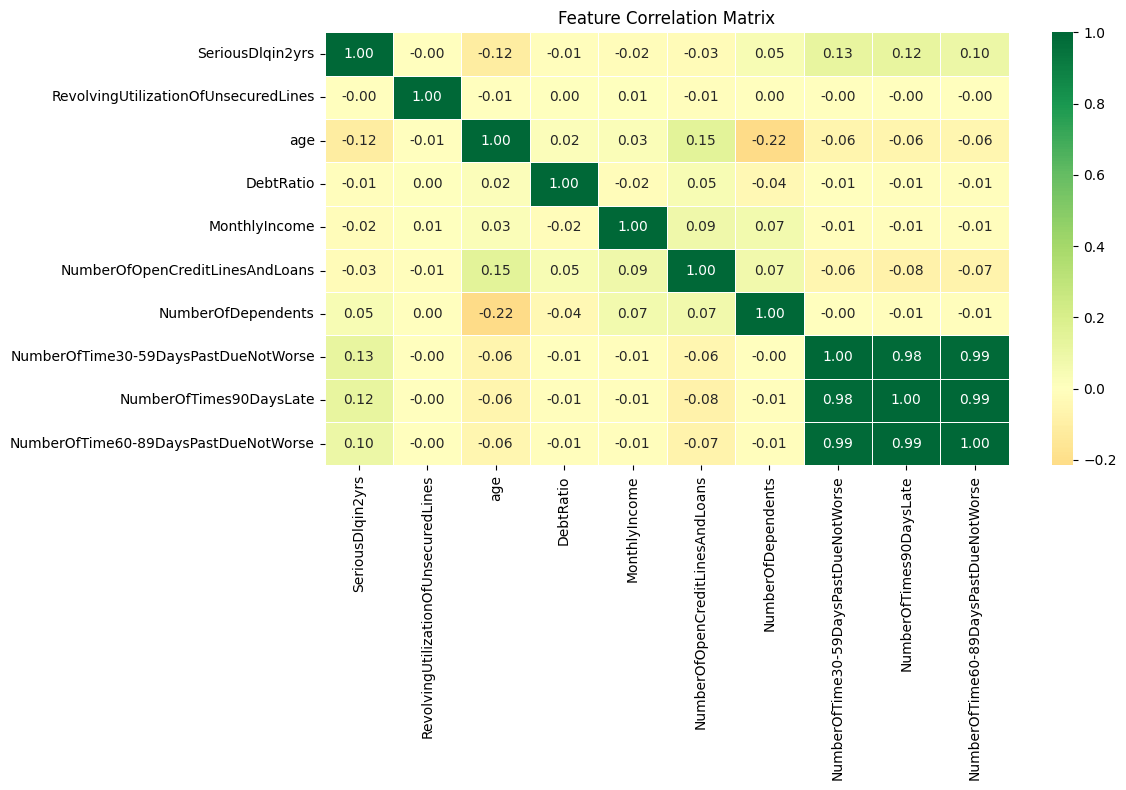

In [44]:
plt.figure(figsize=(12,8))

corr_cols = ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 
             'age', 'DebtRatio', 'MonthlyIncome',
             'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents',
             'NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse']

sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, linewidths=0.5)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [45]:
# Cap utilization and debt ratio at 1 (anything above is a data error)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
df['DebtRatio'] = df['DebtRatio'].clip(0, 1)

# Cap monthly income at 99th percentile (remove extreme outliers)
income_cap = df['MonthlyIncome'].quantile(0.99)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(0, income_cap)

print(f"Income capped at: {income_cap}")
print(df[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']].describe())

Income capped at: 23000.0
       RevolvingUtilizationOfUnsecuredLines      DebtRatio  MonthlyIncome
count                         150000.000000  150000.000000  150000.000000
mean                               0.319196       0.466287    6142.445313
std                                0.349481       0.355455    3835.678657
min                                0.000000       0.000000       0.000000
25%                                0.029867       0.175074    3903.000000
50%                                0.154181       0.366508    5400.000000
75%                                0.559046       0.868254    7400.000000
max                                1.000000       1.000000   23000.000000


In [46]:
# 1. Total delinquencies (combine all 3 late payment columns into one)
df['TotalDelinquencies'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] + 
                             df['NumberOfTimes90DaysLate'] + 
                             df['NumberOfTime60-89DaysPastDueNotWorse'])

# 2. Debt to Income Ratio (classic banking metric)
df['DebtToIncome'] = df['DebtRatio'] * df['MonthlyIncome']

# 3. Income per dependent (financial stress indicator)
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# 4. Is young borrower flag (we saw <35 defaults more)
df['IsYoung'] = (df['age'] < 35).astype(int)

# 5. High utilization flag
df['HighUtilization'] = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.8).astype(int)

print(df[['TotalDelinquencies', 'DebtToIncome', 
          'IncomePerDependent', 'IsYoung', 'HighUtilization']].head(10))

   TotalDelinquencies  DebtToIncome  IncomePerDependent  IsYoung  \
0                   2   7323.197016         3040.000000        0   
1                   0    316.878123         1300.000000        0   
2                   2    258.914887         3042.000000        0   
3                   0    118.963951         3300.000000        1   
4                   1    573.290985        23000.000000        0   
5                   0   1314.624392         1750.000000        0   
6                   0   5400.000000         5400.000000        0   
7                   0    734.790059         3500.000000        0   
8                   0   5400.000000         5400.000000        1   
9                   0  13944.690723         7666.666667        0   

   HighUtilization  
0                0  
1                1  
2                0  
3                0  
4                1  
5                0  
6                0  
7                0  
8                0  
9                0  


In [47]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [48]:
pip install --upgrade imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Model Building
Applied SMOTE to fix class imbalance (6.7% default rate).
Trained Logistic Regression with StandardScaler.
ROC-AUC: 0.76 on holdout test set.

In [49]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Define features and target
drop_cols = ['SeriousDlqin2yrs', 'age_bin', 'util_bin', 'utilization_capped']
X = df.drop(columns=drop_cols)
y = df['SeriousDlqin2yrs']

# Split first (always split BEFORE applying SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42,
                                                      stratify=y)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 111979, 1: 8021}
After SMOTE: {0: 111979, 1: 111979}


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the features (logistic regression needs this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train_sm)

print("Model trained successfully!")
print(f"Number of features: {X_train_sm.shape[1]}")

Model trained successfully!
Number of features: 16


              precision    recall  f1-score   support

           0       0.96      0.82      0.88     27995
           1       0.17      0.53      0.26      2005

    accuracy                           0.80     30000
   macro avg       0.57      0.67      0.57     30000
weighted avg       0.91      0.80      0.84     30000

ROC-AUC Score: 0.7612


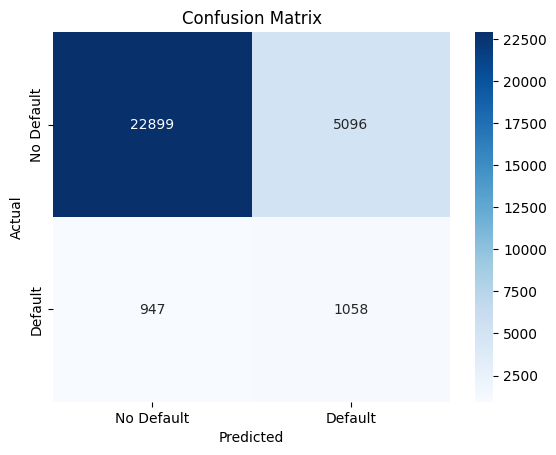

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [52]:
# Add default probability to dataframe
X_test_df = pd.DataFrame(X_test_scaled, columns=X_train_sm.columns)
X_test_df['DefaultProbability'] = y_prob
X_test_df['ActualDefault'] = y_test.values

# Create risk bands
def risk_band(prob):
    if prob < 0.1:
        return 'Low Risk'
    elif prob < 0.3:
        return 'Medium Risk'
    elif prob < 0.5:
        return 'High Risk'
    else:
        return 'Very High Risk'

X_test_df['RiskBand'] = X_test_df['DefaultProbability'].apply(risk_band)

print(X_test_df['RiskBand'].value_counts())
print()
print(X_test_df.groupby('RiskBand')['ActualDefault'].mean() * 100)

RiskBand
Medium Risk       11111
Low Risk           7723
Very High Risk     6154
High Risk          5012
Name: count, dtype: int64

RiskBand
High Risk          8.998404
Low Risk           1.683284
Medium Risk        3.294033
Very High Risk    17.192070
Name: ActualDefault, dtype: float64


## Credit Risk Scorecard
Assigned default probabilities to risk bands:
- Low Risk: 1.7% default rate
- Medium Risk: 3.3%
- High Risk: 9.0%
- Very High Risk: 17.2%
Built 4-panel dashboard visualizing model performance.

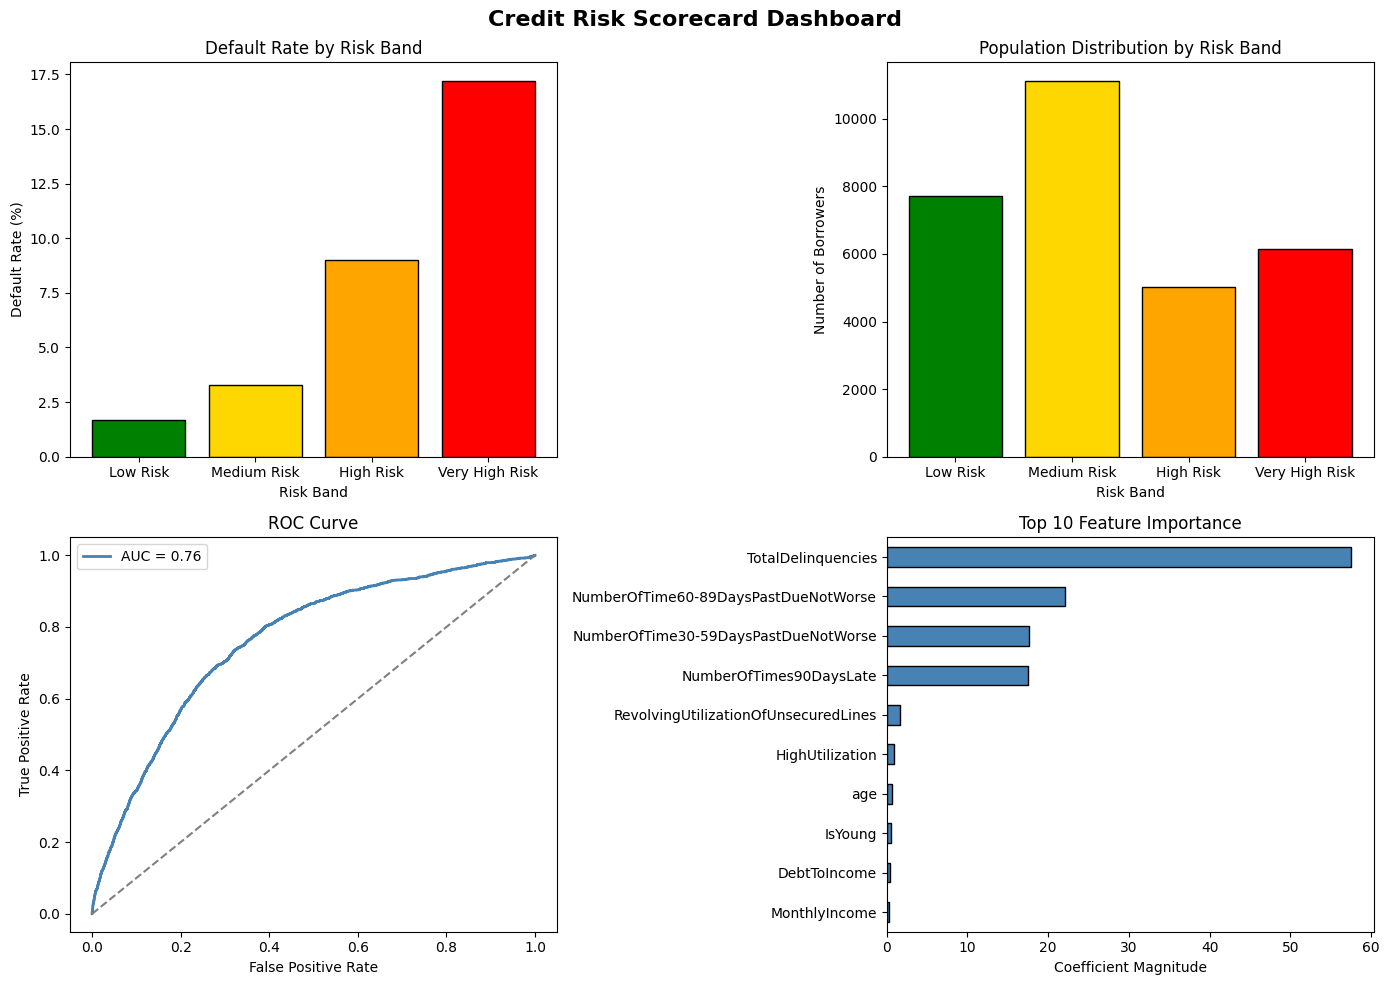

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Risk Scorecard Dashboard', fontsize=16, fontweight='bold')

# Panel 1 — Default rate by risk band
risk_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
default_rates = [X_test_df.groupby('RiskBand')['ActualDefault'].mean()[r]*100 for r in risk_order]

axes[0,0].bar(risk_order, default_rates, color=['green','gold','orange','red'], edgecolor='black')
axes[0,0].set_title('Default Rate by Risk Band')
axes[0,0].set_ylabel('Default Rate (%)')
axes[0,0].set_xlabel('Risk Band')

# Panel 2 — Population distribution across risk bands
pop_counts = [X_test_df['RiskBand'].value_counts()[r] for r in risk_order]
axes[0,1].bar(risk_order, pop_counts, color=['green','gold','orange','red'], edgecolor='black')
axes[0,1].set_title('Population Distribution by Risk Band')
axes[0,1].set_ylabel('Number of Borrowers')
axes[0,1].set_xlabel('Risk Band')

# Panel 3 — ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1,0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = 0.76')
axes[1,0].plot([0,1], [0,1], color='gray', linestyle='--')
axes[1,0].set_title('ROC Curve')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend()

# Panel 4 — Top feature importance
coefficients = pd.Series(model.coef_[0], index=X_train_sm.columns)
top_features = coefficients.abs().sort_values(ascending=True).tail(10)
top_features.plot(kind='barh', ax=axes[1,1], color='steelblue', edgecolor='black')
axes[1,1].set_title('Top 10 Feature Importance')
axes[1,1].set_xlabel('Coefficient Magnitude')

plt.tight_layout()
plt.savefig('credit_risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()